# Project 8: Unveiling the Android App Market
**Oasis Infobyte - Level 2**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Generate Google Play Store Dataset

In [2]:
np.random.seed(42)
n = 1000
categories = ['Tools','Entertainment','Education','Business','Lifestyle',
              'Medical','Sports','Productivity','Social','Finance',
              'Shopping','News','Travel','Music','Photography']
category = np.random.choice(categories, n)
rating = np.round(np.random.uniform(1.0, 5.0, n), 1)
reviews = np.random.randint(10, 5000000, n)
size_mb = np.random.uniform(1, 100, n)
installs_opts = ['1,000+','5,000+','10,000+','50,000+','100,000+','500,000+','1,000,000+','5,000,000+']
installs = np.random.choice(installs_opts, n)
app_type = np.random.choice(['Free','Paid'], n, p=[0.92,0.08])
price = np.where(app_type=='Free', 0.0, np.round(np.random.uniform(0.99,29.99,n),2))
content_rating = np.random.choice(['Everyone','Teen','Mature 17+','Everyone 10+'], n)

df = pd.DataFrame({
    'App': ['App_'+str(i) for i in range(1,n+1)],
    'Category': category,
    'Rating': rating,
    'Reviews': [f'{r:,}' for r in reviews],
    'Size': [f'{round(s,1)}M' for s in size_mb],
    'Installs': installs,
    'Type': app_type,
    'Price': price,
    'Content_Rating': content_rating
})
df.loc[np.random.choice(df.index,30),'Rating'] = np.nan
print('Shape:', df.shape)
df.head()

Shape: (1000, 9)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating
0,App_1,Sports,2.0,"4,257,960",58.3M,"5,000,000+",Free,0.0,Teen
1,App_2,Business,2.1,"265,808",76.2M,"1,000+",Free,0.0,Everyone 10+
2,App_3,Travel,1.8,"1,530,824",10.8M,"100,000+",Free,0.0,Everyone
3,App_4,Photography,4.5,"1,883,386",89.1M,"1,000,000+",Free,0.0,Mature 17+
4,App_5,Shopping,4.0,"3,891,123",2.2M,"500,000+",Free,0.0,Everyone


## Step 2: Data Cleaning

In [3]:
df['Reviews'] = df['Reviews'].str.replace(',','').astype(int)
df['Size_MB'] = df['Size'].str.replace('M','').astype(float)
df['Installs_Num'] = df['Installs'].str.replace('+','').str.replace(',','').astype(int)
df['Rating'].fillna(df['Rating'].median(), inplace=True)
print('Missing values remaining:', df.isnull().sum().sum())
print('Data types fixed!')
df[['Category','Rating','Reviews','Size_MB','Installs_Num','Type']].head()

Missing values remaining: 0
Data types fixed!


,Category,Rating,Reviews,Size_MB,Installs_Num,Type
0,Sports,2.0,4257960,58.3,5000000,Free
1,Business,2.1,265808,76.2,1000,Free
2,Travel,1.8,1530824,10.8,100000,Free
3,Photography,4.5,1883386,89.1,1000000,Free
4,Shopping,4.0,3891123,2.2,500000,Free


## Step 3: Category Distribution

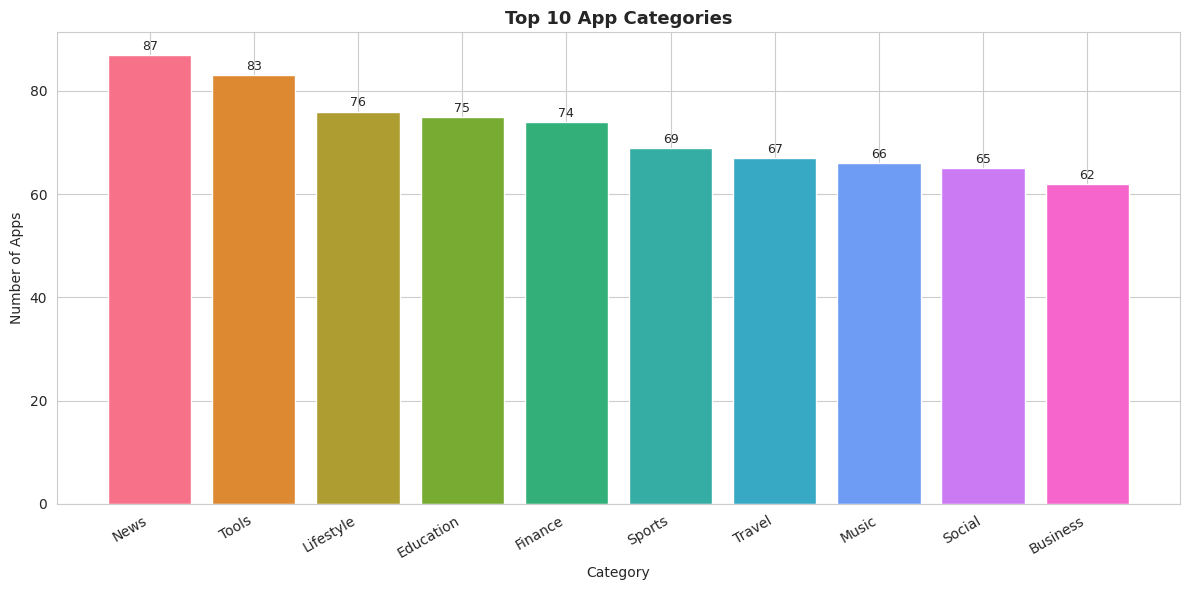

In [4]:
cat_counts = df['Category'].value_counts().head(10)
plt.figure(figsize=(12,6))
bars = plt.bar(cat_counts.index, cat_counts.values, color=sns.color_palette('husl',10))
plt.title('Top 10 App Categories', fontsize=13, fontweight='bold')
plt.xlabel('Category'); plt.ylabel('Number of Apps')
plt.xticks(rotation=30, ha='right')
for bar,val in zip(bars, cat_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, val+1, str(val), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## Step 4: Ratings & Free vs Paid Analysis

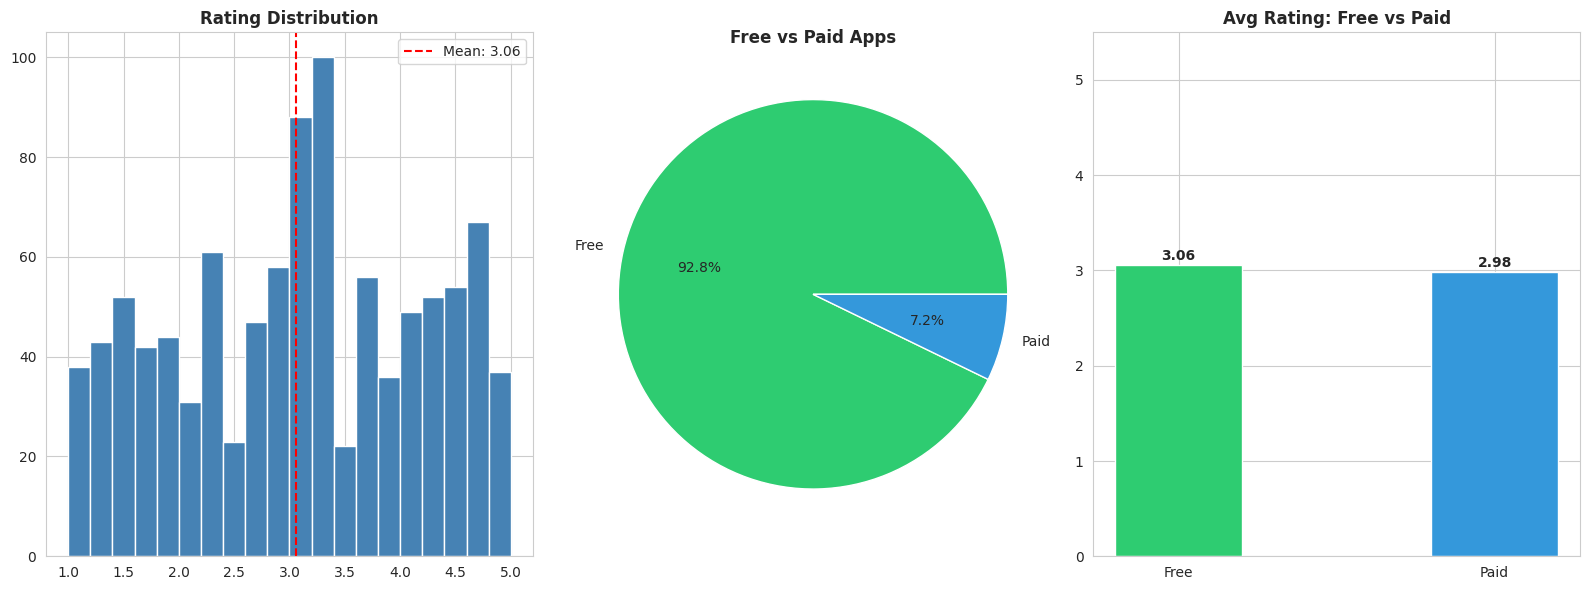

In [5]:
fig, axes = plt.subplots(1,3,figsize=(16,6))
axes[0].hist(df['Rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["Rating"].mean():.2f}')
axes[0].set_title('Rating Distribution', fontweight='bold'); axes[0].legend()

type_counts = df['Type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['#2ECC71','#3498DB'])
axes[1].set_title('Free vs Paid Apps', fontweight='bold')

type_rating = df.groupby('Type')['Rating'].mean()
axes[2].bar(type_rating.index, type_rating.values, color=['#2ECC71','#3498DB'], width=0.4)
axes[2].set_title('Avg Rating: Free vs Paid', fontweight='bold')
axes[2].set_ylim(0,5.5)
for i,v in enumerate(type_rating.values): axes[2].text(i, v+0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 5: Installs & Sentiment Analysis

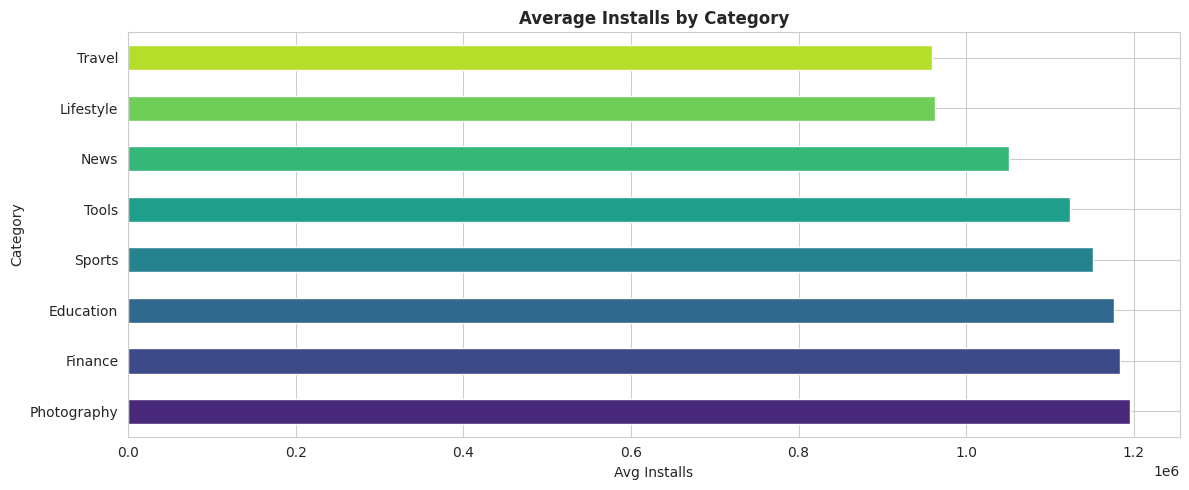

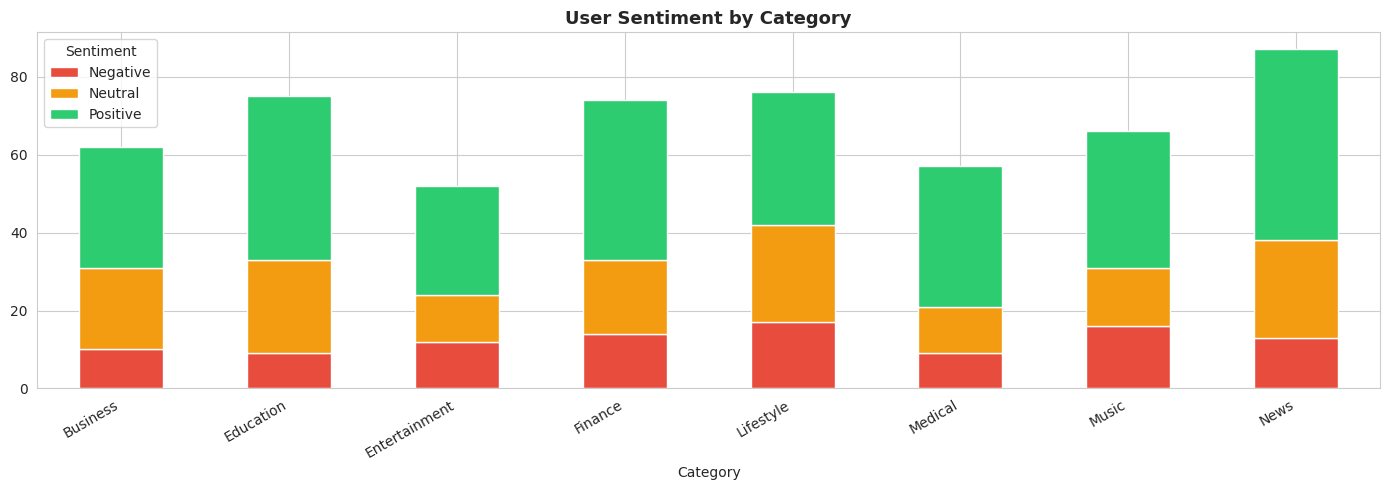

Most popular category: News
Highest rated category: Education
Free apps: 92.8%


In [6]:
top_inst = df.groupby('Category')['Installs_Num'].mean().sort_values(ascending=False).head(8)
plt.figure(figsize=(12,5))
top_inst.plot(kind='barh', color=sns.color_palette('viridis',8))
plt.title('Average Installs by Category', fontsize=12, fontweight='bold')
plt.xlabel('Avg Installs'); plt.tight_layout(); plt.show()

df['Sentiment'] = np.random.choice(['Positive','Neutral','Negative'], n, p=[0.55,0.25,0.20])
cat_sent = df.groupby(['Category','Sentiment']).size().unstack(fill_value=0).head(8)
cat_sent.plot(kind='bar', stacked=True, figsize=(14,5), color=['#E74C3C','#F39C12','#2ECC71'])
plt.title('User Sentiment by Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.legend(title='Sentiment')
plt.tight_layout(); plt.show()

print(f"Most popular category: {df['Category'].value_counts().idxmax()}")
print(f"Highest rated category: {df.groupby('Category')['Rating'].mean().idxmax()}")
print(f"Free apps: {(df['Type']=='Free').mean()*100:.1f}%")